In [1]:
#output figures for representative AN network model with sleep-wake dynamics  Fig4, FigS12, S13, S14

import os
import sys
import matplotlib.pyplot as plt
from scipy import integrate

from tqdm import tqdm


from scipy.signal import find_peaks
from scipy.signal import periodogram
from scipy import signal
import scipy


import pickle
import gc
import traceback


from collections import deque
import itertools
import numpy as np
import pandas as pd


sys.path.append('../')
sys.path.append('../anmodel')


import anmodel

import pickle


fs = 20
fs_l = 15

OK
OK


In [8]:
#read dynamics data
rdir = "../AN_network/"
bifur = "_pre"
model_pre = "AN"
op = "_net_aup"
model_op= op +"_th0"
cr_op="_net_aup_crw"  #_net_rup_crw

date_i = "2023_12_6_7_10"# "2023_3_9_0_5"




get_c_r_w=True
th_complement = True


NE=64
Ip = 20
NI = int(NE*Ip/(100-Ip));
con_M = 1.0
con_M_in = 1.0
con_ex_ex = 0.01
con_ex_in = 0.01
con_in_ex = 0.01
con_in_in = 0.01
cpre_r = 1.0
cpost_r =1.0

Sp_ini = 0.9
K_ini = 0.1
z_ini = 0.0
th_sp=0.3

if not "astdp" in model_op:
    #STDP
#     pars_lr = {'th_p': 1.1636705351704562, 'th_d': 0.7352536527795901, 'gp': 4284.022452465799, 'gd': 745.2206498707948, 'tau_ca_pre': 5.767112722393848, 'tau_ca_post': 10.971009388843335, 'sig': 4.09175314008905, 'tau_s': 985342.6022786312}

    pars_lr = {'th_p': 1.204935656, 'th_d': 0.766636049, 'gp': 3982.537819, 'gd': 981.2049, 'tau_ca_pre': 44.22872557, 'tau_ca_post': 15.16415759, 'sig': 13.29251082, 'tau_s': 1302672.696}

    r=2.5
    if "noise" in model_op:
        alpha = 1000000.0 #ca2+ dependent
        beta = 0.23 # after auto activation
        ap = 0.002#, Ca -> Sp
        bp = 10000.0 #curve
        adp = 0.318055 #SP -> K
        bdp = 14.8941 # curve
        adp2 = 33.2361 # w*r-b*a+I+z(t) -> Sp
        bdp2 = 7.4081 #curve
        tau_camk = 5000
        tau_k = 50000

        w = 37.9513
        b = 75.6176
        I=3.66472
        th=51.8847
        sig_n=26.9548

    elif "th0" in model_op:
        alpha = 1100000.0 #ca2+ dependent
        beta = 0.25 # after auto activation
        adp = 0.65 #SP -> K  
        bdp = 80.0 # curve  30.0
        adp2 = 0.0 # w*r-b*a+I+z(t) -> Sp
        bdp2 = 0.25 #curve#3
        tau_camk = 2500
        tau_k = 10000
        w = 100.0
        b = 80.0  #71
        I= -18.0
        th= 0.0
        sig_n=0.0

        ap = 0.002#, Ca -> Sp
        bp = 10000.0 #curve

    max_con = 4.0

else:
    #Anti-stdp
    pars_lr ={'th_p': 0.7080335639809356, 'th_d': 1.011108947831775, 'gp': 2797.4098759769054, 'gd': 6816.224064000065, 'tau_ca_pre': 5.546, 'tau_ca_post': 10.762, 'sig': 3.511231729915912, 'tau_s': 1519975.3011223024} 
    r=2.5
    if "noise" in model_op:
        alpha = 1000000.0 #ca2+ dependent
        beta = 0.23 # after auto activation
        ap = 0.002#, Ca -> Sp
        bp = 10000.0 #curve
        adp = 0.318055 #SP -> K
        bdp = 14.8941 # curve
        adp2 = 33.2361 # w*r-b*a+I+z(t) -> Sp
        bdp2 = 7.4081 #curve
        tau_camk = 5000
        tau_k = 50000

        w = 37.9513
        b = 75.6176
        I=3.66472
        th=51.8847
        sig_n=26.9548

    elif "th0" in model_op:
        alpha = 1100000.0 #ca2+ dependent
        beta = 0.25 # after auto activation
        adp = 0.65 #SP -> K  
        bdp = 80.0 # curve  30.0
        adp2 = 0.0 # w*r-b*a+I+z(t) -> Sp
        bdp2 = 0.25 #curve#3
        tau_camk = 2500
        tau_k = 10000
        w = 100.0
        b = 80.0  #71
        I= -18.0
        th= 0.0
        sig_n=0.0

        ap = 0.002#, Ca -> Sp
        bp = 10000.0 #curve

    max_con = 5.5

gp = round(pars_lr['gp'],3)
gd =round(pars_lr['gd'],3)
sig = round(pars_lr["sig"],4)
tau_ca_pre = round(pars_lr['tau_ca_pre'],3)
tau_ca_post =round(pars_lr['tau_ca_post'],3)
pars_lr['tau_ca_pre']=tau_ca_pre
pars_lr['tau_ca_post']=tau_ca_post
pars_lr['gp']= gp
pars_lr['gd']=gd
pars_lr['sig']=sig

tau_ss =[pars_lr['tau_s']]


rho_ini = 0.5
smin_ampa =0.5
smax_ampa =1.5
T = 300000
Tp = 5000

tbs = int(T/Tp)


init = "r"
seed = 6
con_log = True
ex=ex_in=-1.8

T_crw = 150000  #ms


ex_w=ex
ex_in_w=ex_w


ex_w=ex
ex_in_w=ex_w


nowdir = os.getcwd()
pre_dir = nowdir +"/"


nowdir = os.getcwd()
pre_dir = nowdir +"/"

if con_log==False:
    model_name = model_pre + model_op+  bifur

else:
    model_name = model_pre+ model_op + bifur
    model_name_cr =  model_pre+ cr_op + bifur
    
if get_c_r_w==True:
    cpre_r=1.0
    cpost_r=1.0
    pars_lr_pre = pars_lr.copy()
    pars_lr_pre["tau_s"]=0.0                 
    params_lr_str_pre = str(1.0) + " " + str(1.0) +" " 
    for k, v in pars_lr_pre.items():
        params_lr_str_pre += str(pars_lr_pre[k])
        params_lr_str_pre+= " "       
    if con_log==True:
        cr_drc =rdir+"/cadyn_dir_crw/{}/param_{}/NE{}_NI{}/conM{}_SD{}_conMin{}_inSD{}/Spini{}_Kini{}_zini{}/exp{}_{}_{}_{}_{}_{}/taucamk{}_tauk{}/w{}_b{}_I{}_th{}_sign{}/T_{}/ex{}_exin{}/".format(model_name_cr, date_i, NE,NI,con_M,con_ex_ex,con_M_in, con_in_in,Sp_ini, K_ini, z_ini, alpha,beta,adp,bdp,adp2,bdp2, tau_camk, tau_k,w,b,I,th,sig_n,T_crw,ex,ex)
    print("cr_drc", cr_drc)
    crw_path = cr_drc +"taupre{}_taupost{}_smaxcon{}_smaxampa{}_c_r_w.txt".format(tau_ca_pre,tau_ca_post,max_con, 1.0)
    
    if not os.path.exists(crw_path):
        print("{} note found".format(crw_path))
    else:
   
        c_r_f = open(crw_path, "r")
        lines = c_r_f.read()
        ls=lines.split("\n")
        cpre_m = ls[0]
        cpost_m = ls[1]
        cpre_r = float(ls[2])
        cpost_r  = round(float(ls[3]),5)
        div = 0.7/float(cpre_m)
        print("cpre_m", cpre_m)

    # for th_p in th_ps:
    if th_complement ==True:
        th_p = pars_lr["th_p"]/div
        pars_lr["th_p"] = round(th_p,4)
        th_d = pars_lr["th_d"]/div
        pars_lr["th_d"] = round(th_d,4)

    for tau_s in tau_ss:
        if tau_s != 0.0:
            taus_inv=1/tau_s
            pars_lr["tau_s"] =f"{taus_inv:,.8f}" 
            # tau_s =  pars_lr["tau_s"] 

        else:
            pars_lr["tau_s"] = 0.0



        if tau_s ==0.0:
            drc =rdir + "/con_cu_i/{}/param_{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/Spini{}_Kini{}_zini{}/exp{}_{}_{}_{}_{}_{}/taucamk{}_tauk{}/w{}_b{}_I{}_th{}_sign{}/ex{}_exin{}/maxcon{}_smaxampa{}/taupre{}_taupost{}/seed_{}/init_{}/T{}_Tp{}/".format(model_name,date_i,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,  Sp_ini,  K_ini, z_ini, alpha,beta,adp,bdp,adp2,bdp2, tau_camk, tau_k,w,b,I,th,sig_n,ex,ex_in,max_con,1.0, pars_lr["tau_ca_pre"],pars_lr["tau_ca_post"], seed,init,T,Tp)
        else:
            drc =rdir+"/con_cu_i/{}/param_{}/NE{}_NI{}/conM{}_conSD{}_conMin{}_conSDin{}/Spini{}_Kini{}_zini{}/exp{}_{}_{}_{}_{}_{}/taucamk{}_tauk{}/w{}_b{}_I{}_th{}_sign{}/ex{}_exin{}/maxcon{}_sminampa{}_smaxampa{}/thp{}_thd{}_gp{}_gd{}_taupre{}_taupost{}_sig{}/tausinv_{}/seed_{}/init_{}/T{}_Tp{}/".format(model_name, date_i, NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,  Sp_ini,  K_ini, z_ini, alpha,beta, adp,bdp,adp2,bdp2, tau_camk, tau_k,w,b,I,th,sig_n, ex, ex_in, max_con,smin_ampa,smax_ampa,pars_lr["th_p"],pars_lr["th_d"],pars_lr["gp"],pars_lr["gd"],pars_lr["tau_ca_pre"],pars_lr["tau_ca_post"],pars_lr["sig"],pars_lr["tau_s"], seed,init,T,Tp)
            fig_dir = rdir+"/cadyn_dir_lrsw/{}/param_{}/NE{}_NI{}/conM{}_SD{}_conMin{}_inSD{}/Spini{}_Kini{}_zini{}/exp{}_{}_{}_{}_{}_{}/taucamk{}_tauk{}/w{}_b{}_I{}_th{}_sign{}/T_{}/ex{}_exin{}/thp{}_thd{}_gp{}_gd{}_taupre{}_taupost{}_sig{}/maxcon{}_sminampa{}_smaxampa{}/tausinv_{}".format(model_name,date_i,NE, NI,con_M, con_ex_ex,con_M_in, con_in_in,  Sp_ini, K_ini, z_ini, alpha,beta,adp,bdp,adp2,bdp2, tau_camk, tau_k,w,b,I,th,sig_n,T, ex, ex_in,pars_lr["th_p"],pars_lr["th_d"],pars_lr["gp"],pars_lr["gd"],pars_lr["tau_ca_pre"],pars_lr["tau_ca_post"],pars_lr["sig"], max_con,smin_ampa,smax_ampa,pars_lr["tau_s"])

        print("drc" ,drc)

        drc_neu = drc + "neu/"
        drc_syn = drc + "syn/"
    

    for i in range(int(NE+NI)):
    #     if i > 0:
    #         continue
        for s in range(int(NE+NI)):
            pre_file = drc_syn+  "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"Sp"+str(s)+"-"+str(i)+"_"+str(0)+".bin"
            
    #         print(pre_file)
            if os.path.exists(pre_file):
                print("file exist")
                break
                

#calc dt 
N=NE+NI
for n in range(int(N)):
    if n>0:
        continue

    for tb in range(tbs):
#         print("tb", tb)
        v_file = drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(tb)+".bin" 
        f2= open(v_file, "rb")
        rectype = np.dtype(np.float64)
        v_tb = np.fromfile(f2, dtype=rectype)
    #         print("v_tb", v_tb.shape)
        if tb==0:
            v=v_tb
        else:
            v=np.append(v, v_tb)
        f2.close()
dt = round(T/len(v),4)
print("dt", dt)

x=np.arange(0,T,dt)/1000  #sec

cr_drc ../AN_network//cadyn_dir_crw/AN_net_aup_crw_pre/param_2023_12_6_7_10/NE64_NI16/conM1.0_SD0.01_conMin1.0_inSD0.01/Spini0.9_Kini0.1_zini0.0/exp1100000.0_0.25_0.65_80.0_0.0_0.25/taucamk2500_tauk10000/w100.0_b80.0_I-18.0_th0.0_sign0.0/T_150000/ex-1.8_exin-1.8/
cpre_m 0.03533722432330251
drc ../AN_network//con_cu_i/AN_net_aup_th0_pre/param_2023_12_6_7_10/NE64_NI16/conM1.0_conSD0.01_conMin1.0_conSDin0.01/Spini0.9_Kini0.1_zini0.0/exp1100000.0_0.25_0.65_80.0_0.0_0.25/taucamk2500_tauk10000/w100.0_b80.0_I-18.0_th0.0_sign0.0/ex-1.8_exin-1.8/maxcon4.0_sminampa0.5_smaxampa1.5/thp0.0608_thd0.0387_gp3982.538_gd981.205_taupre44.229_taupost15.164_sig13.2925/tausinv_0.00000077/seed_6/init_r/T300000_Tp5000/
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exist
file exis

In [4]:
model_name

'AN_net_aup_th0__pre'

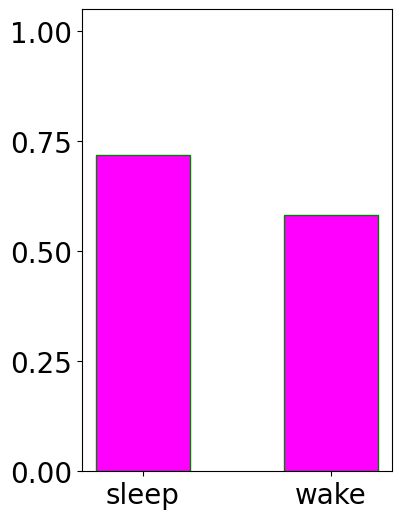

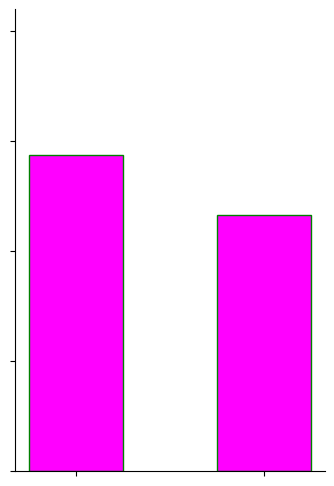

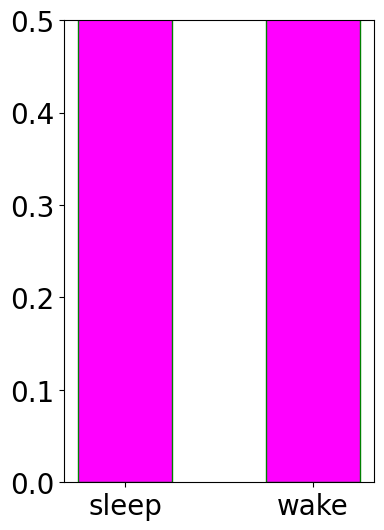

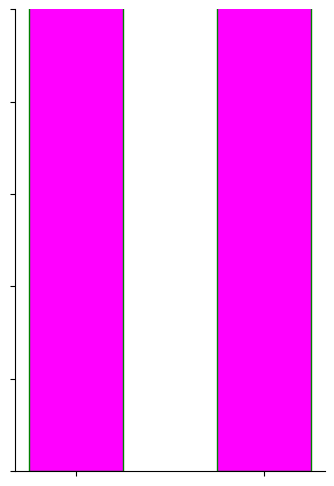

In [6]:
#mean and CV of synaptic efficacy in sleep and wake periods 
x_sw= ["sleep", "wake"]
path = fig_dir +"_rhosw.npy"
sw_rho = np.load(path)
plt.figure(figsize=(4,6))
plt.bar(x_sw, sw_rho, color="magenta",edgecolor='green',width = 0.5)


plt.yticks(fontsize = fs)
plt.xticks(fontsize = fs)
plt.yticks(np.arange(0,1.05, 0.25))
plt.ylim(0,1.05)
plt.show()

    #article
plt.figure(figsize=(4,6))
plt.bar(x_sw, sw_rho, color="magenta",edgecolor='green',width = 0.5)
plt.xlabel('',fontsize = fs)
plt.ylabel('', fontsize = fs)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.yticks(np.arange(0,1.05, 0.25))
plt.ylim(0,1.05)


ax = plt.gca()
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


plt.savefig("{}_{}_N{}_ex{}_rhosw.SVG".format(model_name, date_i, NE+NI, ex))
plt.show()


#npy
x_sw= ["sleep", "wake"]
path = fig_dir +"_cvsw.npy"
sw_rho = np.load(path)
plt.figure(figsize=(4,6))
plt.bar(x_sw, sw_rho, color="magenta",edgecolor='green',width = 0.5)


plt.yticks(fontsize = fs)
plt.xticks(fontsize = fs)
plt.yticks(np.arange(0,0.505, 0.1))
plt.ylim(0,0.5)
plt.show()

    #article
plt.figure(figsize=(4,6))
plt.bar(x_sw, sw_rho, color="magenta",edgecolor='green',width = 0.5)
plt.xlabel('',fontsize = fs)
plt.ylabel('', fontsize = fs)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.yticks(np.arange(0,0.505, 0.1))
plt.ylim(0,0.5)


ax = plt.gca()
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)



plt.savefig("{}_{}_N{}_ex{}_cvsw.SVG".format(model_name, date_i, NE+NI, ex))
plt.show()

In [10]:
lim=[0,300] #graph range  sec


In [ ]:
#synaptic efficacy and ratio of molecules in single neuron
colors=["deepskyblue", "darkorange", "green", "magenta"]

for i in range(int(NE+NI)):
    if i > 0:
        continue
    for s in range(int(NE+NI)):
        pre_file = drc_syn+  "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"Sp"+str(s)+"-"+str(i)+"_"+str(0)+".bin"
#         print(pre_file)
        if os.path.exists(pre_file):
            print("file exist")
            plt.figure(figsize=(15, 4))
            plt.yticks(np.arange(0, 1.05, 0.5))
            for tb in range(tbs):
                sp_file = drc_syn+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"Sp"+str(s)+"-"+str(i)+"_"+str(tb)+".bin"
                fsp= open(sp_file, "rb")
                rectype = np.dtype(np.float64)
                sp_tb = np.fromfile(fsp, dtype=rectype).astype("float32")
                if tb==0:
                    sp=sp_tb
                else:
                    sp=np.append(sp, sp_tb).astype("float32")
                fsp.close()
                
            plt.plot(x, sp, label="r", color=colors[0])
            
            
            for tb in range(tbs):
                k_file = drc_syn+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"K"+str(s)+"-"+str(i)+"_"+str(tb)+".bin"
                fk= open(k_file, "rb")
                rectype = np.dtype(np.float64)
                k_tb = np.fromfile(fk, dtype=rectype).astype("float32")
                if tb==0:
                    k=k_tb
                else:
                    k=np.append(k, k_tb).astype("float32")
                fk.close()
                
            plt.plot(x, k, label="a", color=colors[1])  
                
                
            plt.ylabel("Ratio of molecule", fontsize = fs)
            plt.xlabel('Time (sec)',fontsize = fs)
            plt.xlim(lim[0], lim[1])
            plt.ylim(0,1.05)
#                 plt.xlim(0, 90000)
            plt.xticks(fontsize = fs_l)
            plt.yticks(fontsize = fs_l)
 
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0,fontsize=fs)


            plt.gca().spines['right'].set_visible(False)
            plt.gca().spines['top'].set_visible(False)

            plt.savefig("{}_{}_N{}_ex{}_Spk_{}-{}.SVG".format(model_name, date_i, 0, ex, lim[0],lim[1]))
            plt.show()
            
            
            plt.figure(figsize=(15, 4))
            plt.yticks(np.arange(0, 1.05, 0.5))
            for tb in range(tbs):
                rho_file = drc_syn+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"rho"+str(s)+"-"+str(i)+"_"+str(tb)+".bin"
                frho= open(rho_file, "rb")
                rectype = np.dtype(np.float64)
                rho_tb = np.fromfile(frho, dtype=rectype).astype("float32")
                if tb==0:
                    rho=rho_tb
                else:
                    rho=np.append(rho, rho_tb).astype("float32")
                frho.close()
            plt.plot(x, rho)  
                
            plt.ylabel("synaptic efficacy", fontsize = fs)
            plt.xlabel('Time (sec)',fontsize = fs)
            plt.xlim(lim[0], lim[1])
            plt.ylim(0,1.05)
            plt.xticks(fontsize = fs_l)
            plt.yticks(fontsize = fs_l)
            
          
            plt.gca().spines['right'].set_visible(False)
            plt.gca().spines['top'].set_visible(False)
#             plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)

            plt.savefig("{}_{}_N{}_ex{}_rho_{}-{}.SVG".format(model_name, date_i, 0, ex, lim[0], lim[1]))
            plt.show()
            
#             if c==1:
#                 break
#         else:
#             print("{} not found".format(pre_file))

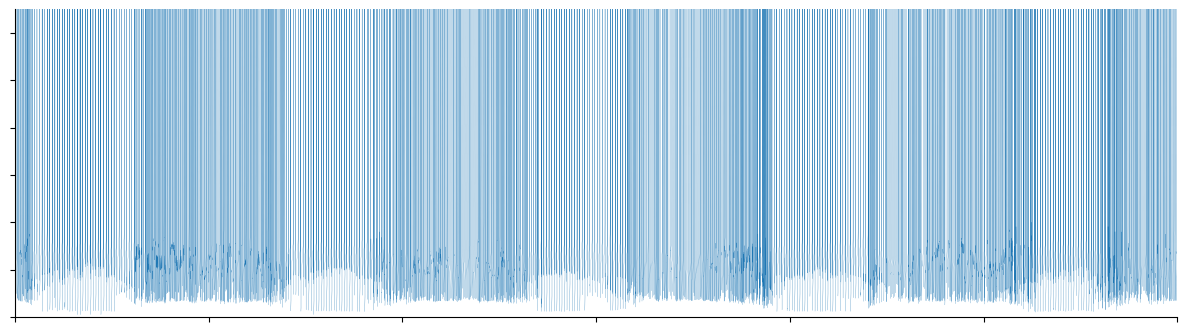

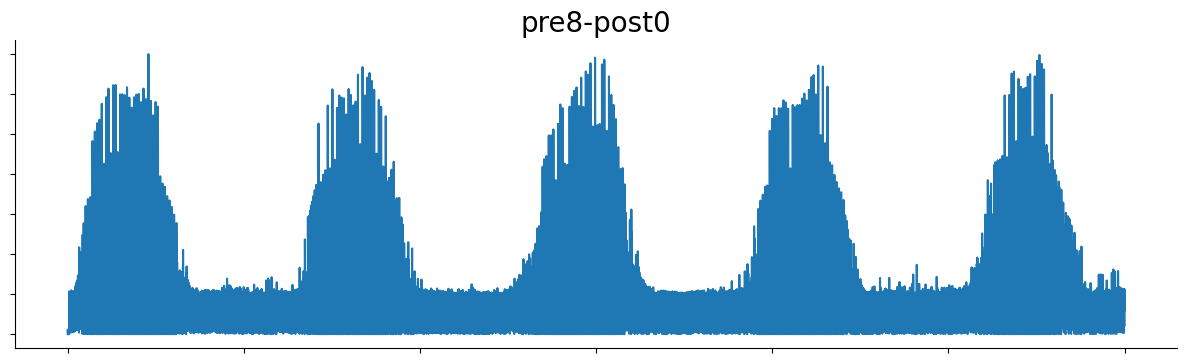

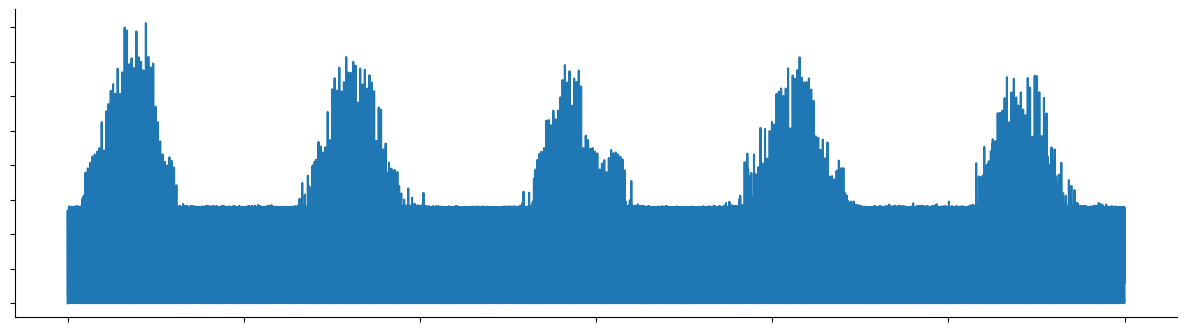

ca_syn [0.0000000e+00 5.4535769e-05 1.1993231e-03 ... 2.0658907e-02 2.0636968e-02
 2.0615060e-02]


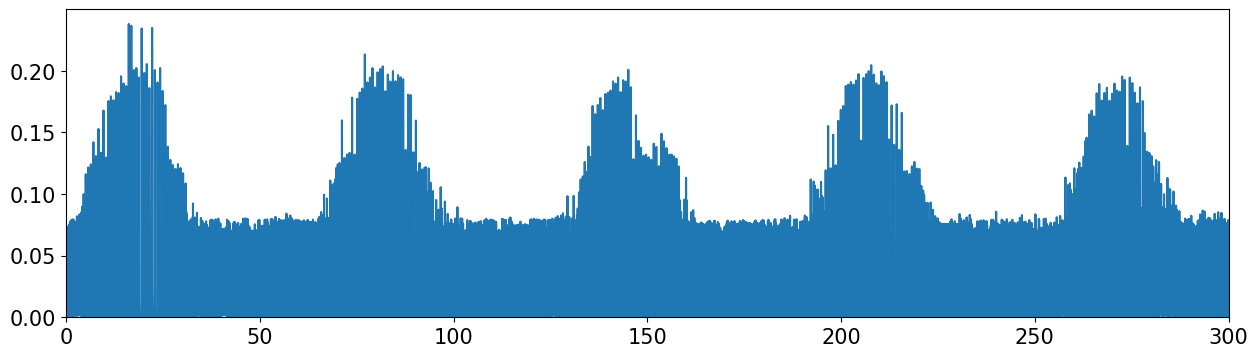

ca_syn [0.0000000e+00 5.4535769e-05 1.1993231e-03 ... 2.0658907e-02 2.0636968e-02
 2.0615060e-02]


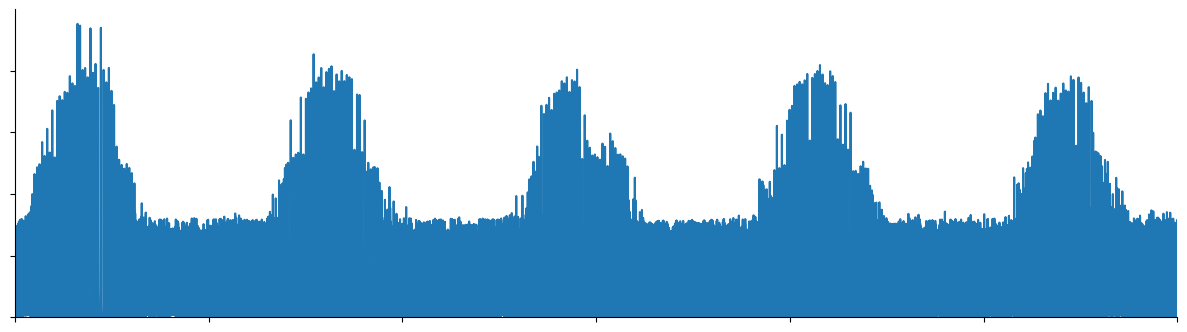

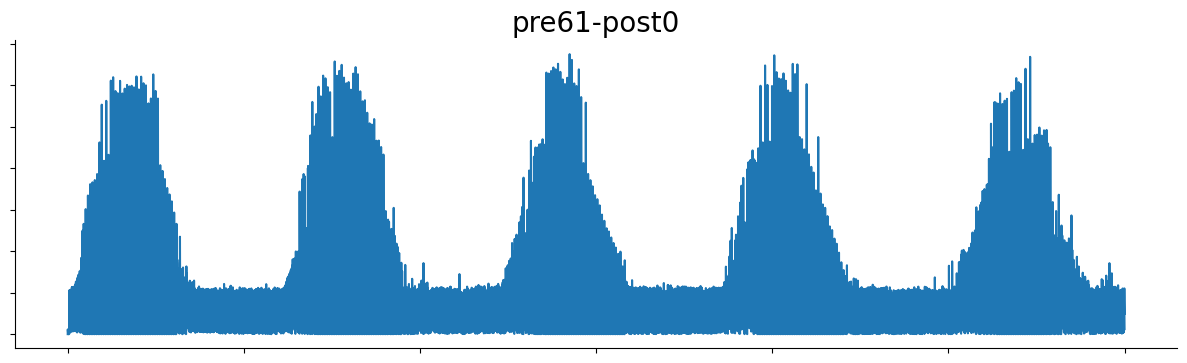

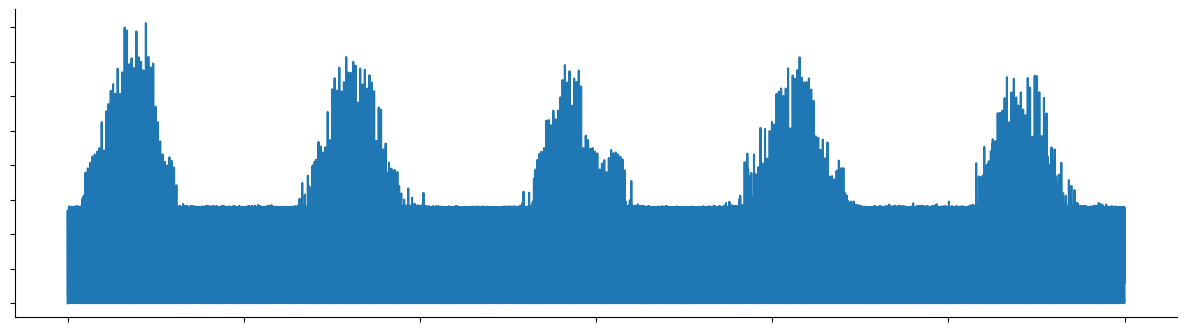

ca_syn [0.0000000e+00 5.4535769e-05 1.1993231e-03 ... 1.9572848e-02 1.9551335e-02
 1.9529849e-02]


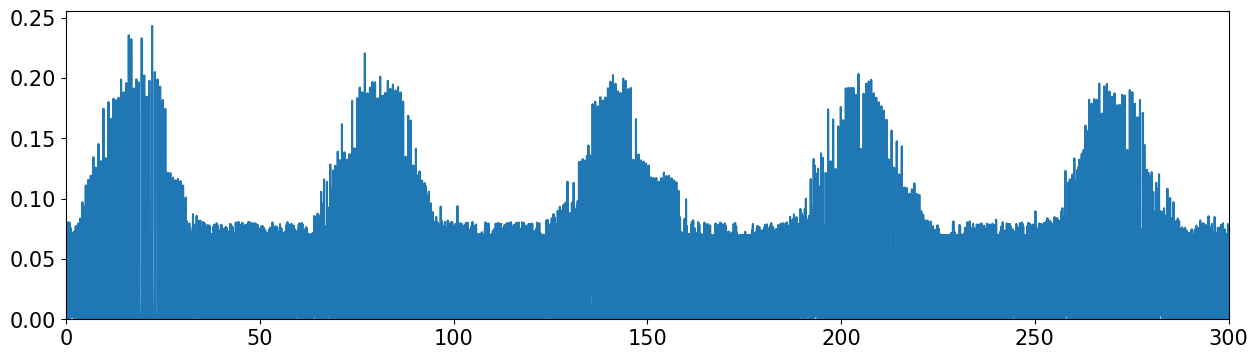

ca_syn [0.0000000e+00 5.4535769e-05 1.1993231e-03 ... 1.9572848e-02 1.9551335e-02
 1.9529849e-02]


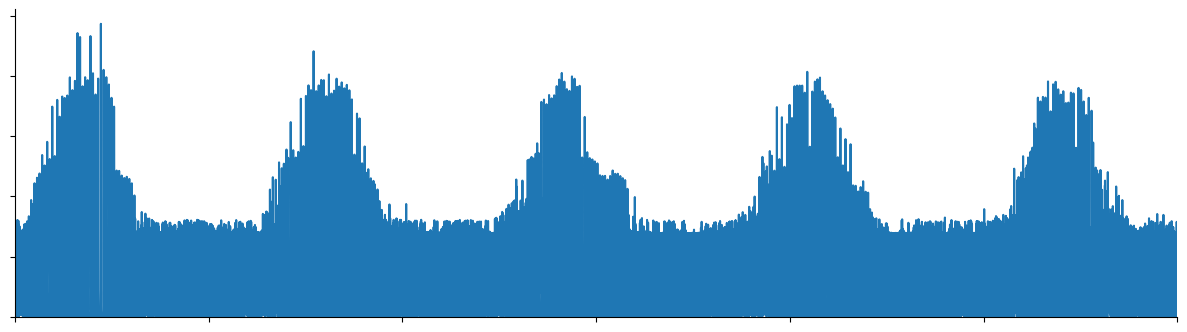

In [13]:
#volage,  synaptic Ca2+
x=np.arange(0,T,dt)/1000  #"sec"

N=NE+NI
for n in range(int(N)):
    if n>0:
        continue

    for tb in range(tbs):
#         print("tb", tb)
        v_file = drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(tb)+".bin" 
        f2= open(v_file, "rb")
        rectype = np.dtype(np.float64)
        v_tb = np.fromfile(f2, dtype=rectype)
#         print("v_tb", v_tb.shape)
        if tb==0:
            v=v_tb
        else:
            v=np.append(v, v_tb)
        f2.close()
    plt.figure(figsize=(15, 4))
    plt.plot(x,v, linewidth=0.1)
    plt.ylabel("mV", fontsize = fs)
    plt.xlabel('Time (sec)',fontsize = fs)
    # plt.xlim(0, 300)
    plt.xlim(lim[0], lim[1])
    #     plt.xlim(0, 100000)
    plt.ylim(-100,30)
    plt.xticks(fontsize = fs)
    plt.yticks(fontsize = fs)


#     plt.xlabel('',fontsize = fs)
#     plt.ylabel('', fontsize = fs)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
#     plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)

    plt.savefig("{}_{}_N{}_ex{}_mV_{}-{}.SVG".format(model_name, date_i,  0, ex,lim[0],lim[1]))

    plt.show()
    
    c=0
        
    for s in range(int(NE+NI)):
        cpre_file = drc_syn+  "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
        if os.path.exists(cpre_file):
#                 print(cpre_file)
            for tb in range(tbs):
                cpre_file =drc_syn+  "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"cpre"+str(s)+"-"+str(n)+"_"+str(tb)+".bin"         
                fcpre= open(cpre_file, "rb")
                rectype = np.dtype(np.float64)
                cpre_tb = np.fromfile(fcpre, dtype=rectype).astype("float32")
                if tb==0:
                    cpre=cpre_tb
                else:
                    cpre=np.append(cpre, cpre_tb).astype("float32")
                fcpre.close()
#             plt.figure(figsize=(15, 4))
#             plt.title("pre{}-post{}".format(s, n), fontsize = fs)
#             plt.plot(x,cpre)
# #             plt.ylim(0, 0.5)
#             plt.xlabel('Time (sec)',fontsize = fs)
#             plt.ylabel("cpre", fontsize = fs)
#             plt.xticks(fontsize = fs_l)
#             plt.yticks(fontsize = fs_l)
#             plt.xlabel('',fontsize = fs)
#             plt.ylabel('', fontsize = fs)
#             plt.gca().spines['right'].set_visible(False)
#             plt.gca().spines['top'].set_visible(False)
#             plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)

#             plt.savefig("{}{}_N{}-{}_ex{}_cpre.SVG".format(date_i, bifur, s,n, ex))
#             plt.show()

            for tb in range(tbs):
                cpost_file =drc_syn+  "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"cpost"+str(s)+"-"+str(n)+"_"+str(tb)+".bin"
                fcpost= open(cpost_file, "rb")
                rectype = np.dtype(np.float64)
                cpost_tb = np.fromfile(fcpost, dtype=rectype).astype("float32")
                if tb==0:
                    cpost=cpost_tb
                else:
                    cpost=np.append(cpost, cpost_tb).astype("float32")
                fcpost.close()
#             plt.figure(figsize=(15, 4))
# #                     plt.title("pre{}-post{}".format(s, post_i), fontsize = fs)
#             plt.plot(x,cpost)
#             plt.xlabel('Time (sec)',fontsize = fs)
#             plt.ylabel("cpost", fontsize = fs)
#             plt.xticks(fontsize = fs_l)
#             plt.yticks(fontsize = fs_l)
# #             plt.xlabel('',fontsize = fs)
# #             plt.ylabel('', fontsize = fs)
#             plt.gca().spines['right'].set_visible(False)
#             plt.gca().spines['top'].set_visible(False)
# #             plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)

# #             plt.savefig("{}{}_N{}-{}_ex{}_cpost.SVG".format(date_i, bifur, s,n, ex))
#             plt.show()
    
            plt.figure(figsize=(15, 4))
#                     plt.title("pre{}-post{}".format(s, post_i), fontsize = fs)
            plt.plot(x,cpre+cpost)
            print("ca_syn", cpost+cpre)
            plt.xlabel('Time (sec)',fontsize = fs)
            #             plt.xlim(50000, 90000)
            #             plt.ylim(0, 0.5)
            plt.ylabel("Ca2+_syn", fontsize = fs)
            plt.xticks(fontsize = fs_l)
            plt.yticks(fontsize = fs_l)
            plt.xlim(lim[0], lim[1])
            plt.ylim(0,)

#             plt.xlabel('',fontsize = fs)
#             plt.ylabel('', fontsize = fs)

            plt.show()

            plt.figure(figsize=(15, 4))
#                     plt.title("pre{}-post{}".format(s, post_i), fontsize = fs)
            plt.plot(x,cpre+cpost)
            print("ca_syn", cpost+cpre)
            plt.xlabel('Time (sec)',fontsize = fs)
#             plt.xlim(50000, 90000)
#             plt.ylim(0, 0.5)
            plt.ylabel("Ca2+_syn", fontsize = fs)
            plt.xticks(fontsize = fs_l)
            plt.yticks(fontsize = fs_l)
            plt.xlim(lim[0], lim[1])
            plt.ylim(0,)
            
#             plt.xlabel('',fontsize = fs)
#             plt.ylabel('', fontsize = fs)
            plt.gca().spines['right'].set_visible(False)
            plt.gca().spines['top'].set_visible(False)
#             plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)

            plt.savefig("{}{}_N_ex{}_syn_Ca_{}-{}.SVG".format(date_i, bifur, ex, lim[0], lim[1]))
            plt.show()
            
#             c+=1
#             if c==1:
#                 break
        

In [30]:

def fre_spike_i(v, T, dt):
    
    if np.any(np.isinf(v)) or np.any(np.isnan(v)):
        print("fre_spike: nan")
        return "Excluded",0, 0, np.zeros(int(T/dt), dtype="int8")
    else:
#         wavech =WaveCheck(1000)
#         pattern = wavech.pattern(v, T, dt, pr=False)
        detv: np.ndarray = signal.detrend(v)
        max_potential: float = max(detv)
        f: np.ndarray  # Array of sample frequencies
        spw: np.ndarray  # Array of power spectral density or power spectrum
        f, spw = periodogram(detv, fs=1/dt*1000)
        maxamp: float = max(spw)
        nummax: int = spw.tolist().index(maxamp)
        maxfre: float = f[nummax]

#         ntraverse: int = 0
#         ms = 1
#         for k in range(len(v)-1):
#             if k+ms < len(v)-1:
#                 if (v[k]+20) * (v[k+ms]+20) < 0:
#                     ntraverse += 1
#         nspike= (ntraverse/2)/(T/(2*1000))/20
        peaks = find_peaks(v, height=-20)[0]
#         print(peaks)
        peak_np = np.zeros(int(T/dt), dtype="int8")
        peak_np[peaks]=1
        return "not calc", maxfre, len(peaks), peak_np
    

def raster_plot_c(drc_neu, N, ex,ex_in,T, off,lim, points, start):
        fig_save= "{}_{}_N{}_ex{}_ptolr_raster_{}-{}_STDP.png".format(model_name, date_i, N, ex, lim[0], lim[1])
        pdf = PdfPages(fig_save)
        spts = np.zeros((N, int((T-off)/dt)), dtype = "int8")
        for n in range(N):
            # try:
                for tb in range(tbs):
                    v_file = drc_neu+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"N"+str(n)+"_"+str(tb)+".bin" 
                    f2= open(v_file, "rb")
                    rectype = np.dtype(np.float64)
                    v_tb = np.fromfile(f2, dtype=rectype)
                    if tb==0:
                        v=v_tb
                    else:
                        v=np.append(v, v_tb)
                    f2.close()
                pattern, maxfre, sp_c, peak_np = fre_spike_i(v[int(off/dt):int(T/dt)], int(T-off), dt)
                spts[n]= peak_np

       
        
        #article
        fig, axes = plt.subplots(figsize=(16, 4))
        Lt = int(T/dt)
        x2=  np.arange(0,Lt,1)
        for i in range(spts.shape[0]):
            t_sp = x2[spts[i, :] > 0.5]   # spike times
            
            if start=="wake":
                co = ["black", "magenta"]
            else:
                co = ["magenta","black"]
            for t in (t_sp*dt/1000):  #sec
                    

                for m in range(len(points)+1):
                        if m==0:
                            if  t < points[0]:
                                axes.plot(t, i, '.', ms=1, markeredgewidth=0.1, color =co[0])
                                break
                        elif m <= len(points)-1:
                            if points[m-1]<= t and t < points[m]:
                                if m%2==0:
                                    color = co[0]
                                else:
                                    color = co[1]
                                axes.plot(t, i, '.', ms=1, markeredgewidth=0.1, color =color)
                                break
                        elif m==len(points):
                            if t>points[m-1]:
                                if m%2==0:
                                    color = co[0]
                                else:
                                    color = co[1]
                                axes.plot(t, i, '.', ms=1, markeredgewidth=0.1, color =color)
                                break
                                    
        axes.set_xlabel('Time (sec)',fontsize = fs)
        axes.set_ylabel('Neuron ID', fontsize = fs)
        axes.tick_params(labelsize=fs_l)
        axes.set_xlim(lim[0],lim[1])
#         axes.set_rasterized(True)
        
        axes.set_xlabel('',fontsize = fs)
        axes.set_ylabel('', fontsize = fs)
        axes = plt.gca()
        axes.axes.xaxis.set_ticklabels([])
        axes.axes.yaxis.set_ticklabels([])
        axes.spines['right'].set_visible(False)
        axes.spines['top'].set_visible(False)
        
        pdf.savefig(fig)
        
        pdf.close()
        plt.show()
        
        return spts
       
#
       


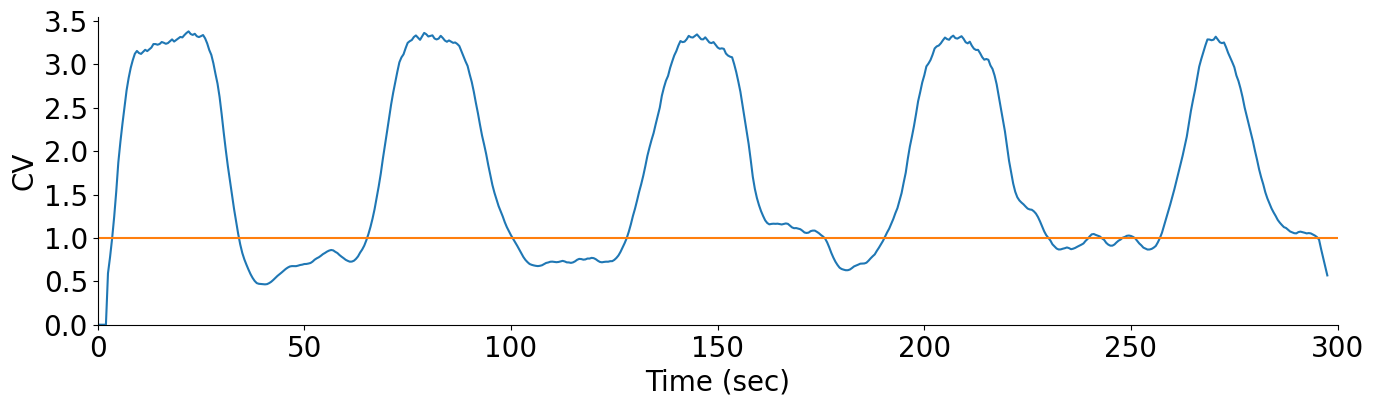

In [20]:
#CV plot
move=500
window=5000
lim=[0,300]
n_conv=10
cv_th=1.0

rectype = np.dtype(np.float64)
cv_li = np.fromfile(fig_dir+"_cv_ori.bin", dtype=rectype)

b = np.ones(n_conv)/n_conv 
cv_ave=np.convolve(cv_li, b, mode="same") 

cv_ave2=np.zeros(int(window/2/1000*1000/move))
cv_ave2 = np.append(cv_ave2, cv_ave)
plt.figure(figsize=(16, 4))
x=np.arange(len(cv_ave2))

plt.plot(x/2, cv_ave2)
y=np.ones(len(cv_ave2))*cv_th
plt.plot(y)

plt.ylabel("CV", fontsize = fs)
plt.xlabel('Time (sec)',fontsize = fs)

plt.ylim(0,)
plt.xlim(lim[0], lim[1])
plt.xticks(fontsize = fs)
plt.yticks(fontsize = fs)

# plt.xlabel('',fontsize = fs)
# plt.ylabel('', fontsize = fs)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)

plt.savefig("{}_{}_N{}_ex{}_CVave_{}-{}.SVG".format(model_name, date_i,  0, ex, lim[0], lim[1]))

plt.show()

In [17]:
#calc sleep and wake time

sw_cv=cv_ave>cv_th

sleep_T_li = []
wake_T_li = []
sleep_m_li =[]
wake_m_li =[]
sleep_v_li =[]
wake_v_li =[]
sw_ratio_li =[]

shifted_arr = np.concatenate(([sw_cv[0]], sw_cv[:-1]))


lengths = []
sw_la=[]


current_length = 1
previous_value = sw_cv[0]
if previous_value==1:
    sw_la.append(1)
else:
    sw_la.append(0)


for value, shifted_value in zip(sw_cv, shifted_arr):
    if value == shifted_value:
        current_length += 1
    else:
        lengths.append(current_length)
        if value==1:
            sw_la.append(1)
        else:
            sw_la.append(0)

        current_length = 1
        previous_value = value


lengths.append(current_length)


print("lengths", lengths)
cumsum  = [0]
psum = 0
for n, l  in enumerate(lengths):
    if n==len(lengths)-1:
        continue
    psum += l
    cumsum.append(psum)


#length -> 
durs =[]
for n, l  in enumerate(lengths):
    s_n = int(cumsum[n]*move/dt)
    end_n = s_n + int(lengths[n]*move/dt)
    durs.append([s_n, end_n])

sleep_durs = [durs[n] for n, sw in enumerate(sw_la) if sw==1 and lengths[n]>=10]
wake_durs = [durs[n] for n, sw in enumerate(sw_la) if sw==0 and lengths[n]>=10]
print("sleep_period", sleep_durs)
print("wake_period", wake_durs)

len_T = [i*move/1000 for i in lengths]  #s 
sleep_time=[len_T[n] for n, sw in enumerate(sw_la) if sw==1 and lengths[n]>=10 and n!=0 and n!=len(lengths)-1]
wake_time=[len_T[n] for n, sw in enumerate(sw_la) if sw==0 and lengths[n]>=10 and n!=0 and n!=len(lengths)-1]


points = []
for i, dur in enumerate(durs):
    if i!=0:
        val = dur[0]
        points.append(val*dt/1000+2.5)
print(points)

lengths [4, 61, 62, 70, 56, 95, 29, 80, 19, 6, 10, 6, 13, 76, 5]
sleep_period [[100000, 1625000], [3175000, 4925000], [6325000, 8700000], [9425000, 11425000], [12775000, 14675000]]
wake_period [[1625000, 3175000], [4925000, 6325000], [8700000, 9425000], [11425000, 11900000], [12050000, 12300000], [12450000, 12775000]]


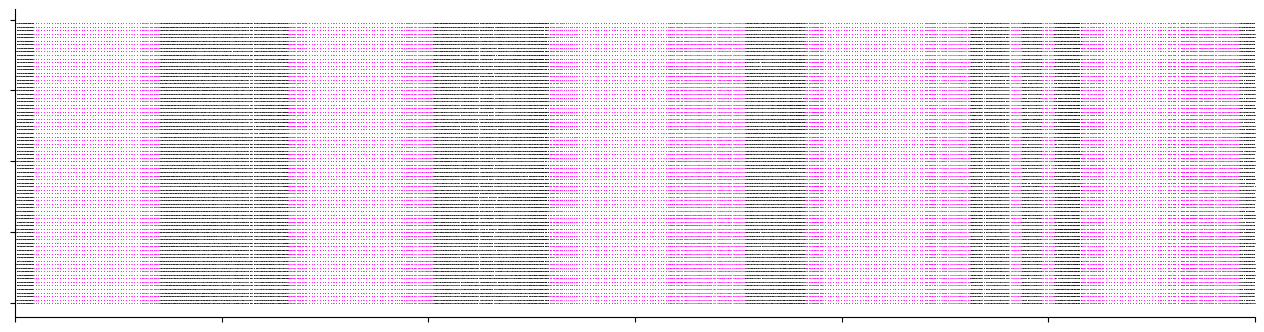

In [31]:
#raster plot

raster_range=300000 #raster range
start_state = "wake"
off=0
N=NE+NI
spts = raster_plot_c(drc_neu, N, ex,ex_in, raster_range, off, lim, points, start_state)

synapse count 128


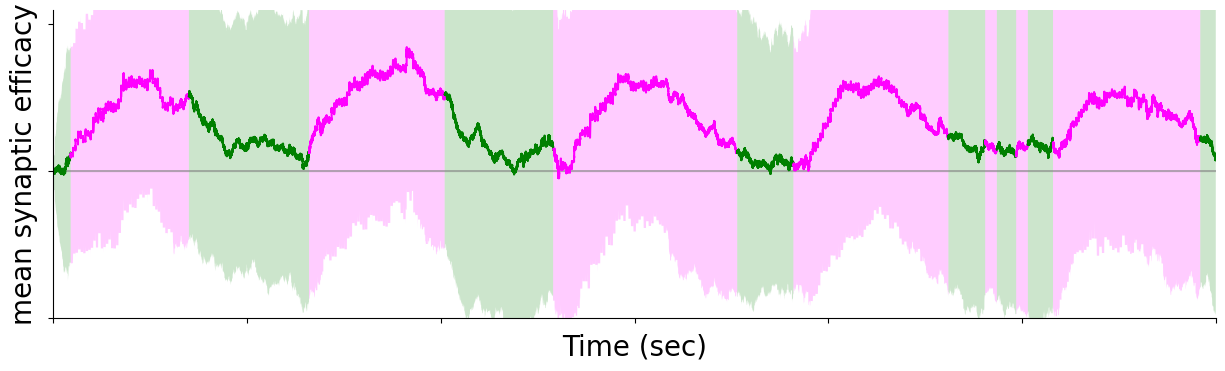

In [27]:
#mean synaptic efficacy with SD

start_state = "wake"
if start_state=="wake":
    co=["green", "magenta"]
else:
    co=[ "magenta", "green"]
    
start_T=0  #ms
rho_range = 300000
x=np.arange(start_T,rho_range,dt)/1000

syN=0
N=NE
syn_li=[]
neu_cons=[]
for n in range(int(N)):
#     if n>=3:
#         continue
    for s in range(int(N)):
        cpre_file = drc_syn+  "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
        if os.path.exists(cpre_file):
            syn_li.append(syN)
            neu_cons.append([s,n])
            syN+=1
            
#             print("file_exist")
print("synapse count", syN)

# syN=6
rho_li = np.zeros((syN, int(rho_range/dt)))
c=0
for n in range(int(N)):
 #   if n>=3:
 #       continue
    for s in range(int(N)):
        cpre_file = drc_syn+  "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"cpre"+str(s)+"-"+str(n)+"_"+str(0)+".bin"
        if os.path.exists(cpre_file):
#             print("file_exist")
            
            for tb in range(tbs):
                rho_file = drc_syn+ "ex"+str(ex)+"_"+"ex_in"+str(ex_in)+"_"+"rho"+str(s)+"-"+str(n)+"_"+str(tb)+".bin"
                frho= open(rho_file, "rb")
                rectype = np.dtype(np.float64)
                rho_tb = np.fromfile(frho, dtype=rectype).astype("float32")
                if tb==0:
                    rho=rho_tb
                else:
                    rho=np.append(rho, rho_tb).astype("float32")
                frho.close()
            rho_li[c] = rho[int(start_T/dt):int(start_T/dt) + int(rho_range/dt)]
            c+=1
            del rho
            gc.collect()

syn_c_M = np.mean(rho_li, axis = 0)
syn_c_SD = np.std(rho_li, axis = 0)    

            
fig = plt.figure(figsize=(15, 4))
ax = fig.add_subplot(111)
yc=np.ones(rho_li.shape[1])*0.5
ax.plot(x, yc, color = "gray", alpha=0.6)

for m in range(len(points)+1):
    if m==0:
        x1_in = np.where(x < points[m])[0]
        x1=np.take(x, x1_in)
        syn_c_M1= np.take(syn_c_M, x1_in)
        syn_c_SD1= np.take(syn_c_SD, x1_in)
        ax.plot(x1, syn_c_M1, color = co[0], label="solid")
        ax.fill_between(x1, syn_c_M1+syn_c_SD1, syn_c_M1-syn_c_SD1, facecolor=co[0], alpha=0.2)
    
    elif m <= len(points)-1:
        x1_in = np.where((x >= points[m-1]) & (x<points[m]))[0]
        x1=np.take(x, x1_in)
        syn_c_M1= np.take(syn_c_M, x1_in)
        syn_c_SD1= np.take(syn_c_SD, x1_in)
        if m%2==0:
            color = co[0]
        else:
            color = co[1]
        
        ax.plot(x1, syn_c_M1, color = color, label="solid")
        ax.fill_between(x1, syn_c_M1+syn_c_SD1, syn_c_M1-syn_c_SD1, facecolor=color, alpha=0.2)
    
    elif m==len(points):
        x1_in = np.where(x >= points[m-1])[0]
        x1=np.take(x, x1_in)
        syn_c_M1= np.take(syn_c_M, x1_in)
        syn_c_SD1= np.take(syn_c_SD, x1_in)
        if m%2==0:
            color = co[0]
        else:
            color = co[1]
        ax.plot(x1, syn_c_M1, color = color, label="solid")
        ax.fill_between(x1, syn_c_M1+syn_c_SD1, syn_c_M1-syn_c_SD1, facecolor=color, alpha=0.2)

        


ax.set_yticks(np.arange(0, 1.05, 0.5))
ax.set_ylim(0, 1.05)
ax.set_xlim(lim[0],lim[1])
# ax.set_rasterized(True)

ax = plt.gca()
ax.set_xlabel('Time (sec)',fontsize = fs)
ax.set_ylabel('mean synaptic efficacy', fontsize = fs)
ax.axes.xaxis.set_ticklabels([])
ax.axes.yaxis.set_ticklabels([])
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.savefig("{}_{}_N{}_ex{}_lr_averho_{}-{}.png".format(model_name, date_i,  N, ex, lim[0], lim[1]))


plt.show()

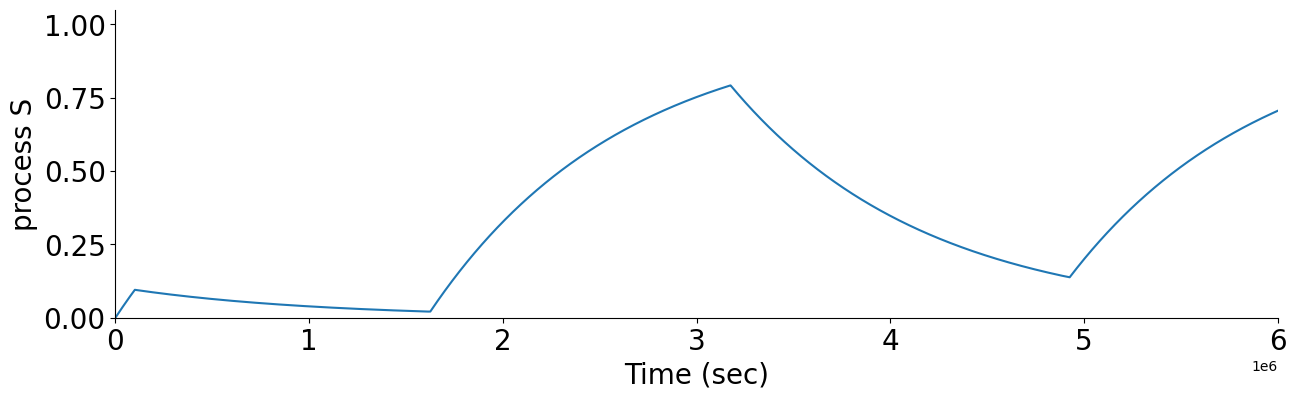

In [28]:
#process_S

UA=1.0
LA=0.0
Ti=20000
Td=20000

rectype = np.dtype(np.float64)
pro_s = np.load(fig_dir+"_pro_s_{}_{}_{}_{}.npy".format(LA,UA,Ti,Td))

plt.figure(figsize=(15, 4))
plt.plot(pro_s)

plt.ylabel("process S", fontsize = fs)
plt.xlabel('Time (sec)',fontsize = fs)
# plt.xlim(lim[0],lim[1])
#     plt.xlim(0, 100000)
plt.ylim(0,1.05)
plt.xlim(lim[0], int(T*2*10*lim[1]/(T/1000)))
plt.xticks(fontsize = fs)
plt.yticks(np.arange(0,1.05,0.25))
plt.yticks(fontsize = fs)

# plt.xlabel('',fontsize = fs)
# plt.ylabel('', fontsize = fs)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
# plt.tick_params(labelbottom=False, labelleft=False, labelright=False, labeltop=False)

plt.savefig("{}_{}_N{}_ex{}_CV_th{}_pros_{}-{}.SVG".format(model_name, date_i,  0, ex,  cv_th, lim[0], lim[1]))



plt.show()